In [1]:
import numpy as np
import arviz as az 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import nest_asyncio
!pip install --upgrade pystan
nest_asyncio.apply()
import stan
from os.path import exists
import pickle
import os
import json
import pickle
%matplotlib inline

from src.model import *
from src.util import *
from src.plotting import *

red =[229/255.0,80/255.0,61/255.0, ]
yellow =np.array([243,213,74])/255
orange = np.array([200,150,100])/255


  Using cached pystan-3.5.0-py3-none-any.whl (13 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.7/411.7 kB 5.4 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
  Using cached clikit-0.6.2-py2.py3-none-any.whl (91 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 MB 35.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.5/114.5 kB 21.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.0/264.0 kB 37.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.6/149.6 kB 8.7 MB/s eta 0:00:00
  Using cached pastel-0.2.1-py2.py3-none-any.whl (6.0 kB)
  Using cached pylev-1.4.0-py2.py3-none-any.whl (6.1 kB)
  Using cached crashtest-0.3.1-py3-none-any.whl (7.0 kB)
  Using cached webargs-8.2.0-py3-none-any.whl (30 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 12.5 MB/s eta 0:00:00
  Using cached appdirs-1.4.4-py2.py3-n

<h1> Setup</h1>

In [2]:
##Set names of your dependent variable, 
##Binary indicator of pre-post,
##Window on either side of the discontinuity (must be symmetric), 
## and User ID column
outcome = 'non_covid'
indicator = 'SU_banned'
window = 30

user_column = 'user_id'

#Make some output directories
make_dir = lambda fname: os.makedirs(fname) if not os.path.exists(fname) else None
make_dir('output')
make_dir('output/figures')
make_dir('output/figures/main')
make_dir('output/figures/SI')
make_dir('output/figures/evaluation')
make_dir('output/tables/')
make_dir('output/posteriors/')
make_dir('output/median_pickles/covid/')
make_dir('output/median_pickles/noncovid/')

#Load model code
with open('./src/model.stan', 'r') as file:
    model_code = file.read() 


<h1>Data Processing</h1>

In [3]:
def select_and_strip(df, user_id, window, indicator, outcome,user_column):
    one_user = df[df[user_column] == user_id]
    #Figure out when the intervention happens, strip before and after.
    start = np.where(one_user[indicator]==True)[0].min()
    one_user = one_user.iloc[start-window:start+window]
    return one_user


def process_one(one_user, folder='/', user_id='none'):
    if (np.sum(one_user[indicator]==True) > (window-1)) :
        print('./output/posteriors'+ folder + str(user_id) + '.json')

        stan_data = make_data_dictionary(one_user,
                         outcome=outcome,
                         indicator=indicator,
                         window=window)
        model, fit = get_fit(stan_data, model_code)
        idata = make_idata(fit, model, stan_data)
        idata.to_json('./output/posteriors'+ folder + str(user_id) + '.json')
        return True
    else: 
        return False
    
def process_data_file(df, window, indicator, outcome, user_column,folder='/', keep=True):
    unique_users = df[user_column].unique()
    status = []
    for uidx in range(len(unique_users)):
        if df[df[user_column] == unique_users[uidx]].shape[0] >= window*2:
            if np.sum(df[df[user_column] == unique_users[uidx]][indicator]==True) > (window-1):
                if keep & (not os.path.exists('./output/posteriors'+ folder + str(unique_users[uidx]) + '.json')):
                    one_user = select_and_strip(df, unique_users[uidx], window, indicator, outcome,user_column)
                    process_one(one_user,folder=folder, user_id=unique_users[uidx])
    return None

def get_change(posterior,adj=True):
    
    idata = az.from_json(posterior)
    
    with_ban =  np.array(np.exp(idata.posterior_predictive.mu_hat))
    without_ban =  np.array(np.exp(idata.posterior_predictive.mu_hat_without_ban))

    return with_ban.reshape(4000,60),  without_ban.reshape(4000,60)



<h3>Process non-covid data</h3>

In [4]:
all_timeseries = pd.read_csv('./dat/all_reliable_amplifier_activity_counts_10_20_22.csv')
super_user_names = all_timeseries['suspended_user'].unique()
outcome = 'non_covid_tweets'
for name in super_user_names:
    make_dir('./output/posteriors/noncovid/' + name)
for idx in range(len(super_user_names)):
    df = all_timeseries[all_timeseries['suspended_user'] == super_user_names[idx]]  
    process_data_file(df, 
                     window, 
                     indicator, 
                     outcome, 
                     user_column,
                     folder='/noncovid/' + super_user_names[idx] + '/noncovid_',keep=True)

In [5]:
outcome = 'covid_tweets'
import glob
super_user_names = all_timeseries['suspended_user'].unique()
outcome = 'covid_tweets'
for name in super_user_names:
    make_dir('./output/posteriors/covid/' + name)
    
for idx in range(len(super_user_names)):
    df = all_timeseries[all_timeseries['suspended_user'] == super_user_names[idx]]  
    process_data_file(df, 
                     window, 
                     indicator, 
                     outcome, 
                     user_column,
                     folder='/covid/' + super_user_names[idx] + '/covid_', keep=True)

<h1> Plotting Function</h1></h1>

In [6]:
def posterior_plot(idata,
                   ylabel='Posts per day',
                   xlabel='Day',
                   window=60,
                   axs=False):

    if axs==False:
        sns.set_style('white')
        sns.set_context('paper', font_scale=1.25)
        plt.figure(figsize=(6,4))
        ax = plt.gca()
    else:
        ax = axs
    plt.sca(ax)

    #We can extract it (it's in log scale, so we take an exp)
    #It is a matrix of 4000 x window*2, containing samples from the posterior predictive distribution
    exp_post = np.exp(idata.posterior_predictive.exp_hat)

    #And plot various credible intervals, perhaps with shading.
    for q in (1,3,6,11, 25,50,75):
        cis = np.nanpercentile(np.array(exp_post).reshape(4000,window*2), q=[0+q/2, 100-q/2],axis=0)
        plt.fill_between(np.arange(window*2), cis[0], cis[1], alpha = q/100,color= orange)

    #Our idata object has actual data, let's plot that
    #Stored as seen below
    plt.scatter(np.arange(window*2), idata.observed_data.y,color=np.array([47,47,56])/255,zorder=2,s=10)


    #exp_hat contains the mean function
    ci = np.nanpercentile(np.exp(np.array(idata.posterior_predictive.exp_hat)).reshape(4000,window*2),
                   axis=0,
                   q=[5.5,50, 94.5])

    #Plot the 94\% credible interval as being shaded
    plt.fill_between(np.arange(window*2), ci[0], ci[2], alpha=.35, color='grey')

    #Plot the median as a line
    plt.plot(np.arange(window*2), ci[1], color=np.array([47,47,56])/255)

    #Clean things up
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.ylim(0,np.max(idata.observed_data.y)*1.5)
    plt.xlim(0,window*2)
    plt.plot([window-1,window-1],
             [0, 4000],
             color=np.array([47,47,56])/255,
             ls='--')
    plt.tight_layout()
    
def adjust(x, window=30):
    return 100*x / np.median(x[:window])




def plot_gini(melted, fit,axs):
    plt.sca(axs)
    codes = pd.Categorical(melted['suspended_user']).codes
    convert_dict = json.load(open('./dat/user_followers_count.json','rb'))
    for code in np.unique(codes):
        account = melted[codes==code].iloc[0]['suspended_user']
        xloc = convert_dict[account]/1000
        mu = np.mean(fit['change'][code])
        plt.scatter(xloc, mu,color='k')#np.array([249,214,73])/255)

        for ps in [3, 6, 11, 25,50,]:
            ci = np.nanpercentile(fit['change'][code], q=[0+ps/2, 100-ps/2])
            plt.plot([xloc, xloc], [ci[0], ci[1]],
                     solid_capstyle='projecting',
                     lw=10,alpha=ps/50*.5,color=yellow)
        plt.ylim(-1, 1)
    plt.plot([0, 600],[0,0], ls='--',color='k') 
    plt.xlim(0,550)
    plt.ylabel('Change in \nGini coefficient')
    plt.xlabel('Followers (thousands)')

def plot_shannon(melted, fit,axs):
    plt.sca(axs)
    codes = pd.Categorical(melted['suspended_user']).codes
    convert_dict = json.load(open('./dat/user_followers_count.json','rb'))
    for code in np.unique(codes):
        account = melted[codes==code].iloc[0]['suspended_user']
        xloc = convert_dict[account]/1000
        mu = np.mean(fit['change'][code])
        plt.scatter(xloc, mu,color='k')#np.array([249,214,73])/255)

        for ps in [3, 6, 11, 25,50,]:
            ci = np.nanpercentile(fit['change'][code], q=[0+ps/2, 100-ps/2])
            plt.plot([xloc, xloc], [ci[0], ci[1]],
                     solid_capstyle='projecting',
                     lw=10,alpha=ps/50*.5,color=red)
    plt.ylim(-2, 2)
    plt.plot([0, 600],[0,0], ls='--',color='k') 
    plt.xlim(0,550)
    plt.ylabel('Change in \nShannon Diversity (bits)')
    plt.xlabel('Followers (thousands)')

def plot_one_su(posteriors_loaded,axs):
    posteriors_all = np.stack([np.array(
    np.exp(
        item.posterior_predictive['mu_hat'][:,:,:])).reshape(4000,window*2)
     for item in posteriors_loaded])
    mu = np.nanmedian(np.median(posteriors_all,axis=0),axis=0)
    axs.plot(np.arange(window*2), mu,color=np.array([47,47,56])/255)

    ci = np.nanpercentile(np.median(posteriors_all,axis=0),q=[3,97],axis=0)
    axs.fill_between(np.arange(window*2), ci[0], ci[1],
                     alpha=.25,color=np.array([47,47,56])/255)


    posteriors_all = np.stack(
        [np.array(
            np.exp(
                item.posterior_predictive['mu_hat_without_ban'][:,:,:])).reshape(4000,window*2)
         for item in posteriors_loaded])
    mu = np.nanmedian(np.nanmedian(posteriors_all,axis=0),axis=0)
    axs.plot(np.arange(window*2)[(window-1):], mu[(window-1):],color=np.array([47,47,56])/255,ls='--')
    
    axs.plot([window-1,window-1],
         [0, 4000],
         color=np.array([47,47,56])/255,
         ls='--') 
    
    ci = np.percentile(np.nanmedian(posteriors_all,axis=0),q=[3,97],axis=0)
    axs.fill_between(np.arange(window*2)[(window-1):], ci[0][(window-1):], 
                     ci[1][(window-1):],
                     alpha=.1,color=np.array([47,47,56])/255)
    axs.set_xlim(0,60)
    axs.set_ylim(0,200)
    axs.set_xlabel('Day')
    axs.set_ylabel('Posts per day')

def plot_su_SI(posterior_names, filter_list):
    fig, axs = plt.subplots(len(posterior_names),1, figsize=(6,18),sharey=True)
    for pidx in range(len(posterior_names)):
        posteriors = glob.glob(posterior_names[pidx] + '*.json')
        posteriors = filter_users(posteriors, filter_list)
        posteriors_loaded = [az.from_json(item) for item in posteriors]
        axs[pidx].set_title(posterior_names[pidx].split('/')[-2])
        plot_one_su(posteriors_loaded,axs[pidx])
        plt.tight_layout()
        


<H2>Figures</h2>

In [7]:
top_users = all_timeseries[all_timeseries['group'] == 'top']['user_id'].unique()
median_users = all_timeseries[all_timeseries['group'] == 'median']['user_id'].unique()

In [9]:
posterior_names = glob.glob('./output/posteriors/covid/*/')
def filter_users(posterior_list, filter_list):
    try: 
        return [item for item in posterior_list if int(item.split('/')[-1].split('.')[0]) in filter_list]
    except:
        return [item for item in posterior_list if int(item.split('/')[-1].split('.')[0].split('_')[-1]) in filter_list]


def plot_posterior_batch(posterior_names, 
                         folder_loc, 
                         filter_list):

    for idx in range(len(posterior_names)):
        loc = folder_loc + posterior_names[idx].split('/')[-2]
        make_dir(loc)
        posteriors = glob.glob(posterior_names[idx] + '*.json')
        posteriors = filter_users(posteriors, top_users)
        for jidx in range(len(posteriors)):
            plt.clf()
            posterior_plot(az.from_json(posteriors[jidx]),axs=plt.gca(),window=window)
            plt.savefig(loc + '/' + posteriors[jidx].split('/')[-1].split('.')[0]\
                        + '.png', dpi=250, transparent=False)
 
    


In [ ]:
plot_posterior_batch(posterior_names, 'output/figures/evaluation/covid/top/', top_users)
plot_posterior_batch(posterior_names, 'output/figures/evaluation/covid/median/', median_users)
plot_posterior_batch(posterior_names, 'output/figures/evaluation/noncovid/top/', top_users)
plot_posterior_batch(posterior_names, 'output/figures/evaluation/noncovid/median/', median_users)


<h3>SI Figures for all users</h3>

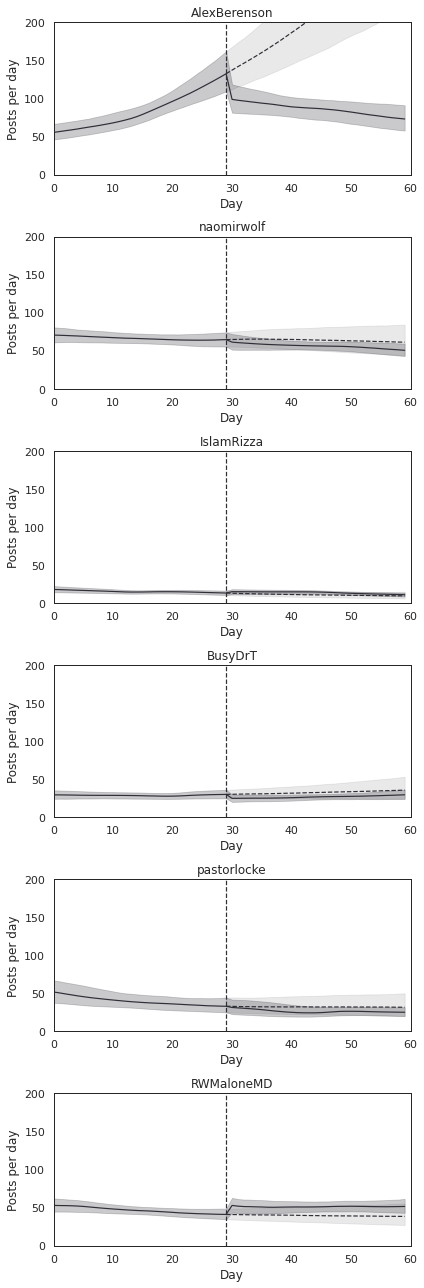

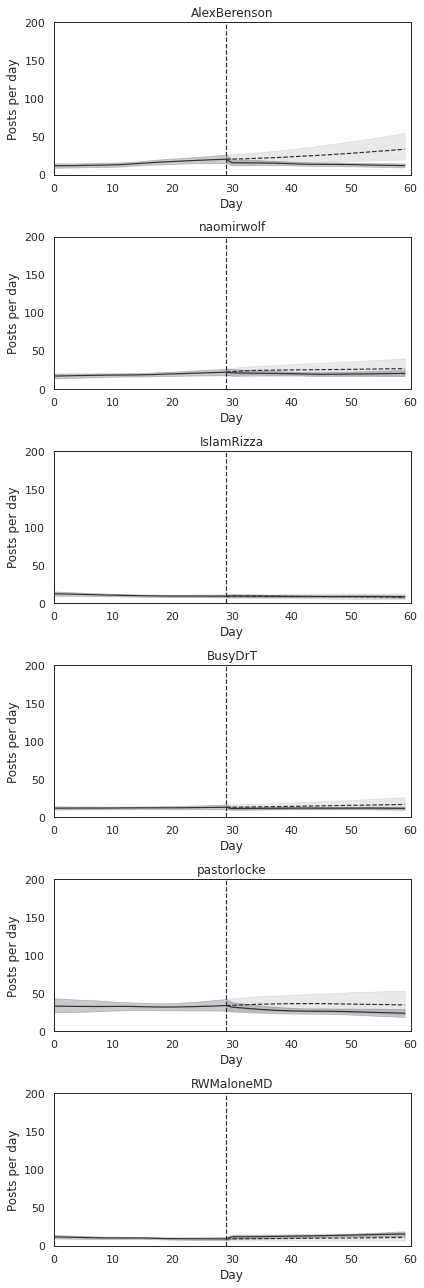

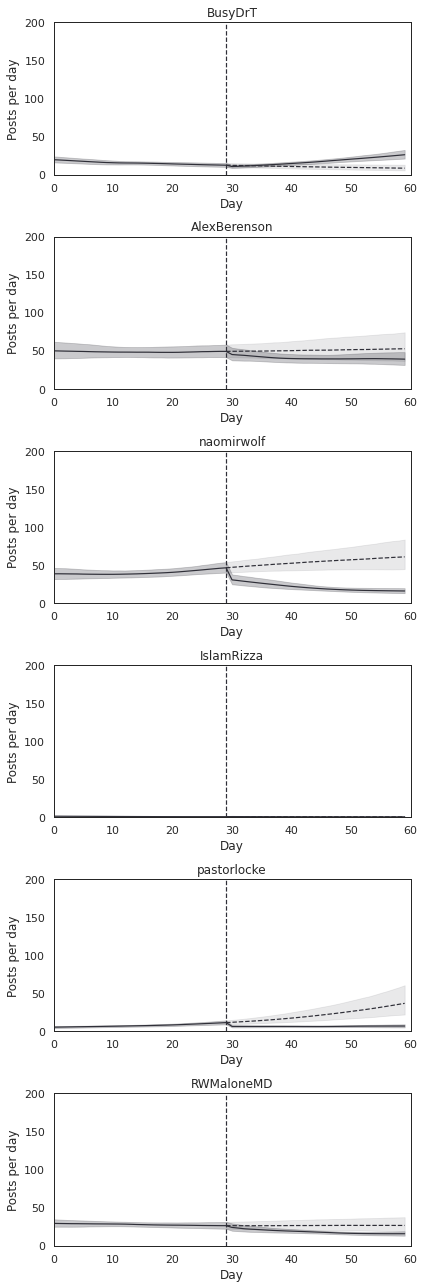

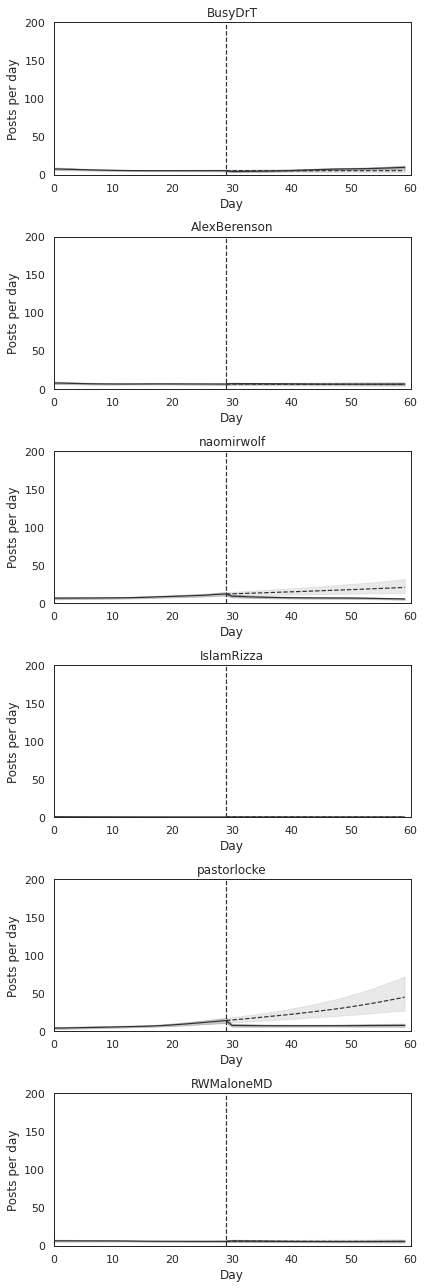

In [369]:
sns.set_style('white')

posterior_names = glob.glob('./output/posteriors/noncovid/*/')

plot_su_SI(posterior_names, top_users)
plt.savefig('./output/figures/SI/SuperUsers_noncovid_top.png', dpi=300, transparent=False)

plot_su_SI(posterior_names, median_users)
plt.savefig('./output/figures/SI/SuperUsers_noncovid_median.png', dpi=300, transparent=False)


posterior_names = glob.glob('./output/posteriors/covid/*/')
plot_su_SI(posterior_names, top_users)
plt.savefig('./output/figures/SI/SuperUsers_covid_top.png', dpi=300, transparent=False)


plot_su_SI(posterior_names, median_users)
plt.savefig('./output/figures/SI/SuperUsers_covid_median.png', dpi=300, transparent=False)


In [ ]:
import multiprocessing 

def extract_pickles(posterior_names, filter_name, save_name):
        
    convert_dict = json.load(open('./dat/user_followers_count.json','rb'))
    plot_dfs = []
    
    for idx in range(len(posterior_names)):
        superuser_name = posterior_names[idx].split('/')[-2]
        followers = convert_dict[superuser_name]
        posteriors = glob.glob(posterior_names[idx] + '*.json')
        posteriors = filter_users(posteriors, filter_name)
        
        # create a process pool that uses all cpus
        with multiprocessing.Pool() as pool:
            temp_data = pool.map(get_change,posteriors)
        
        make_dir('./output/median_pickles/'+ save_name + '/')
        print('./output/median_pickles/'+ save_name + '/'+ superuser_name +'.p')
        with  open('./output/median_pickles/'+ save_name + '/'+ superuser_name +'.p','wb') as f:
            pickle.dump(temp_data,f)

        with_ban = np.median(np.array([item[0] for item in temp_data]),axis=0)
        without_ban = np.median(np.array([item[1] for item in temp_data]),axis=0)
        change = 100*with_ban/without_ban

        immediate = change[:,30]
        final = change[:,-1]
        plot_dfs.append(pd.DataFrame({'User': np.repeat(superuser_name, immediate.size),
                                      'followers': np.repeat(followers, immediate.size),
         'immediate':immediate,
         'final':final}))
    plot_df = pd.concat(plot_dfs)
    plot_df.to_csv('./output/' + save_name + '_plotdf.csv')


posterior_names = glob.glob('./output/posteriors/noncovid/*/')
extract_pickles(posterior_names, top_users, 'noncovid_top')

posterior_names = glob.glob('./output/posteriors/noncovid/*/')
extract_pickles(posterior_names, median_users, 'noncovid_median')

posterior_names = glob.glob('./output/posteriors/covid/*/')
extract_pickles(posterior_names, top_users, 'covid_top')

posterior_names = glob.glob('./output/posteriors/covid/*/')
extract_pickles(posterior_names, median_users, 'covid_median')


In [ ]:
plot_df = pd.concat(plot_dfs)
plot_df.head()

In [ ]:
def plot_su_change(plot_df, which='immediate',axs=axs):
    plt.sca(axs)
    for user in plot_df['User'].unique():
        temp = plot_df[plot_df['User']==user]
        mu = np.mean(temp[which])
        xloc = temp['followers'].values[0]/1000
        plt.scatter(xloc, mu,color=np.array([47,47,56])/255)

        ps = 3

        for ps in [3, 6, 11, 25,50,]:
            ci = np.percentile(temp[which], q=[0+ps/2, 100-ps/2])
            plt.plot([xloc, xloc], [ci[0], ci[1]],
                     solid_capstyle='projecting',
                     lw=10,alpha=ps/50*.3,color=np.array([47,47,56])/255)

    plt.plot([0, 550],[100,100], ls='--',color=np.array([47,47,56])/255)
    plt.xlabel('Followers (thousands)')
    if which=='final':
        label='1-month'
    else:
        label = '1-day'
    plt.ylabel('Median '+label+' follower\n  activity change (%)')
    plt.ylim(0,500)
    plt.xlim(0,550)


In [126]:
posterior_names = glob.glob('./output/posteriors/naomirwolf/*/')
posteriors = glob.glob('./output/posteriors/noncovid/naomirwolf/*.json')
posteriors_loaded = [az.from_json(item) for item in posteriors]



KeyboardInterrupt: 

In [ ]:
#####REDO ANALYSIS FOR SEPARATE GROUPS 




Future exception was never retrieved
future: <Future finished exception=RuntimeError('write: Broken pipe [system:32]')>
concurrent.futures.process._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/opt/conda/lib/python3.9/concurrent/futures/process.py", line 246, in _process_worker
    r = call_item.fn(*call_item.args, **call_item.kwargs)
  File "/opt/conda/lib/python3.9/site-packages/httpstan/services_stub.py", line 47, in _make_lazy_function_wrapper_helper
    return function(*args, **kwargs)  # type: ignore
RuntimeError: write: Broken pipe [system:32]
"""

The above exception was the direct cause of the following exception:

RuntimeError: write: Broken pipe [system:32]


<h2>Figure 1</h2>

In [ ]:
## MAKE FIGURES FOR EVERY POSTERIOR 

In [ ]:
posterior_plot(az.from_json(posteriors[21]),axs=plt.gca(),window=30)


In [ ]:
import string 

fig, axs = plt.subplots(4,1, figsize=(6,11))
sns.set_context('paper', font_scale=1.1)
sns.set_style('white')
selection=20
posterior_plot(az.from_json(posteriors[21]),axs=axs[0],window=30)
plot_one_su(posteriors_loaded,axs[1])
axs[0].set_xlim(0, 59)
axs[1].set_xlim(0, 59)
axs[0].set_ylim(0,150)
axs[1].set_ylim(0,150)
plot_su_change(plot_df, which='immediate',axs=axs[2])
plot_su_change(plot_df, which='final',axs=axs[3])


for n, ax in enumerate(axs):
    ax.text(-0.075, 1.1, string.ascii_uppercase[n], transform=ax.transAxes, 
            size=20, weight='bold')
plt.tight_layout()
plt.savefig('./output/figures/main/Fig1.png', dpi=300, transparent=False)

In [ ]:
posterior_names_covid = glob.glob('./output/posteriors/covid/*/')
posteriors_covid = glob.glob('./output/posteriors/covid/AlexBerenson/*.json')
posteriors_loaded_covid = [az.from_json(item) for item in posteriors]

In [ ]:
plot_dfs_covid = []
convert_dict = json.load(open('./dat/user_followers_count.json','rb'))
for idx in range(len(posterior_names_covid)):
    superuser_name = posterior_names_covid[idx].split('/')[-2]
    followers = convert_dict[superuser_name]
    posteriors_covid = glob.glob(posterior_names_covid[idx] + '*.json')
    
    temp_data =  [get_change(item) for item in posteriors_covid]
    
    with_ban = np.median(np.array([item[0] for item in temp_data]),axis=0)
    without_ban = np.median(np.array([item[1] for item in temp_data]),axis=0)
    change = 100*with_ban/without_ban

    immediate = change[:,30]
    final = change[:,-1]
    plot_dfs_covid.append(pd.DataFrame({'User': np.repeat(superuser_name, immediate.size),
                                  'followers': np.repeat(followers, immediate.size),
     'immediate':immediate,
     'final':final}))
    

In [ ]:
plot_df_covid = pd.concat(plot_dfs_covid)
plot_df_covid

<h1>Diversity Analysis</h1>

<h2>Gini coefficient</h2>

In [ ]:
df_diversity = pd.read_csv('./dat/diversity_measurements.csv')

In [ ]:
gini = df_diversity[df_diversity['measurement']=='gini']

In [ ]:
gini.head()

In [ ]:
gini['id'] = np.arange(gini.shape[0])

In [ ]:
gini

In [ ]:
melted = pd.melt(gini, id_vars=['id','suspended_user'],value_vars=['before_suspension', 'after_suspension'])
sns.kdeplot(melted['value'], hue=melted['variable'],shade=False)
melted.head()
melted['variable'].unique()
melted = melted.dropna()

melted = melted[melted['value'] > 0]

melted['value'].max()



In [ ]:
gini_code = '''

data {
    int<lower=0> N;
    int<lower=0> N_SU;
    vector<lower=0, upper=1>[N] y; 
    int<lower=0> superuser[N];
    int<lower=0, upper=1> after[N]; 
} 

parameters {
    real alpha;
    real<lower=0> after_sigma_group;
    real<lower=0> before_sigma_group;
    vector<lower=0>[N_SU] kappa;
    vector[N_SU] before_SU_tilde;
    vector[N_SU] after_SU_tilde;

}

transformed parameters {
    vector[N_SU] before_su = before_sigma_group * before_SU_tilde;
    vector[N_SU] after_su = after_sigma_group * after_SU_tilde;
}


model { 
    vector[N] mu;
    alpha ~ normal(logit(.57), .5); //Emprical prior for grand mean
    kappa ~ exponential(1);
    before_sigma_group ~ exponential(1);
    after_sigma_group ~ exponential(1);

    before_SU_tilde ~ std_normal(); // non-centered parameterization
    after_SU_tilde ~ std_normal(); // non-centered parameterization

    for (n in 1:N){
        mu[n] = inv_logit(alpha + (1-after[n])*before_su[superuser[n]] + after[n] * after_su[superuser[n]]);
        y[n] ~ beta_proportion(mu[n], kappa[superuser[n]]);

    }

} 

generated quantities {
    vector[N_SU] change;
    vector[N_SU] before_hat;
    vector[N_SU] after_hat;
    vector[N] y_pred;
    vector[N] mu_pred;

    for(n in 1:N) {
        mu_pred[n] = inv_logit(alpha + (1-after[n])*before_su[superuser[n]] + after[n] * after_su[superuser[n]]);
        y_pred[n] = beta_proportion_rng(mu_pred[n], kappa[superuser[n]]); 
    }


    for (s in 1:N_SU){
        before_hat[s] = inv_logit(alpha + before_su[s]);
        after_hat[s] = inv_logit(alpha + after_su[s]);
        change[s] =  after_hat[s] - before_hat[s]; 
    }

} 


'''
gini_data = {'N':melted.shape[0], 
              'after':np.array(melted['variable']=='all_after_suspension').astype('int'),
              'y':melted['value'].values,
             'superuser':pd.Categorical(melted['suspended_user']).codes.astype('int')+1,
             'userid':pd.Categorical(melted['id']).codes.astype('int')+1,
             'F':melted['id'].unique().size,
             'N_SU':melted['suspended_user'].unique().size,

              'ga':2,
               'gb':2}
posterior = stan.build(gini_code, data=gini_data)
fit = posterior.sample(num_chains=4, num_samples=3000)



In [ ]:
az.summary(fit)

In [ ]:
plot_gini(melted,fit,axs=plt.gca())
plt.ylim(-1,1)


In [ ]:
for idx in range(20):
    sns.kdeplot(fit['y_hat'][:,idx],alpha=.1,color=np.array([47,47,56])/255)

<h3>Posterior Predictive</h3>

In [ ]:
sns.kdeplot(melted['value'])
for idx in range(20):
    sns.kdeplot(fit['y_pred'][:,idx],alpha=.1,color='k')

<h2>Shannon Diversity</h2>

In [ ]:
shannon = df_diversity[df_diversity['measurement']=='shannon']

In [ ]:
shannon['id'] = np.arange(shannon.shape[0])

In [ ]:
melted_shannon = pd.melt(shannon, id_vars=['id','suspended_user'],value_vars=['before_suspension', 'after_suspension'])
sns.kdeplot(melted_shannon['value'], hue=melted_shannon['suspended_user'],shade=False, clip=[0,50])
melted_shannon['variable'].unique()
melted_shannon = melted_shannon.dropna()
melted_shannon.head()

melted_shannon = melted_shannon[melted_shannon['value'] > 0]

melted_shannon[melted_shannon['value'] < 2]

In [ ]:
shannon_code = '''

data {
    int<lower=0> N;
    int<lower=0> N_SU;
    vector<lower=0>[N] y; 
    int<lower=0> superuser[N];
    int<lower=0, upper=1> after[N]; 
} 

parameters {
    real alpha;
    real<lower=0> after_sigma_group;
    real<lower=0> before_sigma_group;
    vector<lower=0>[N_SU] kappa;
    vector[N_SU] before_SU_tilde;
    vector[N_SU] after_SU_tilde;

}

transformed parameters {
    vector[N_SU] before_su = before_sigma_group * before_SU_tilde;
    vector[N_SU] after_su = after_sigma_group * after_SU_tilde;
    
}


model { 
    vector[N] mu;

    alpha ~ normal(logit(.57), .5); //Emprical prior for grand mean
    kappa ~ exponential(1);
    before_sigma_group ~ exponential(1);
    after_sigma_group ~ exponential(1);


    before_SU_tilde ~ std_normal(); // non-centered parameterization
    after_SU_tilde ~ std_normal(); // non-centered parameterization

    for (n in 1:N){
        mu[n] = exp(alpha + (1-after[n])*before_su[superuser[n]] + after[n] * after_su[superuser[n]]);
        y[n] ~ gamma(kappa[superuser[n]], mu[n]/kappa[superuser[n]]);

    }

} 


generated quantities {

    vector[N_SU] change;
    vector[N_SU] before_hat;
    vector[N_SU] after_hat;
    vector[N] y_pred;
    vector[N] mu_pred;

    for(n in 1:N) {
        mu_pred[n] = exp(alpha + (1-after[n])*before_su[superuser[n]] + after[n] * after_su[superuser[n]]);
        y_pred[n] = gamma_rng(kappa[superuser[n]], mu_pred[n]/kappa[superuser[n]]); 
    }


    for (s in 1:N_SU){
        before_hat[s] = inv_logit(alpha + before_su[s]);
        after_hat[s] = inv_logit(alpha + after_su[s]);
        change[s] =  after_hat[s] - before_hat[s]; 
    }
} 


'''

shannon_data = {'N':melted_shannon.shape[0], 
              'after':np.array(melted_shannon['variable']=='all_after_suspension').astype('int'),
              'y':melted_shannon['value'].values,
             'superuser':pd.Categorical(melted_shannon['suspended_user']).codes.astype('int')+1,
             'userid':pd.Categorical(melted_shannon['id']).codes.astype('int')+1,
             'F':melted_shannon['id'].unique().size,
             'N_SU':melted_shannon['suspended_user'].unique().size,
              'ga':2,
               'gb':2}
shannon_posterior = stan.build(shannon_code, data=shannon_data)
shannon_fit = shannon_posterior.sample(num_chains=4, num_samples=1000)


In [ ]:
az.summary(shannon_fit)

<h3>Posterior Predictive</h3>

In [ ]:
sns.kdeplot(melted_shannon['value'])
for idx in range(50):
    sns.kdeplot(shannon_fit['y_pred'][:,np.random.choice(np.arange(shannon_fit['y_pred'].shape[1]))],
                                                                   alpha=.1,color='k')

In [ ]:
plot_shannon(melted_shannon,shannon_fit,axs=plt.gca())


<h2>Figure 2</h2>

In [ ]:
import string 

fig, axs = plt.subplots(4,1, figsize=(6,11))
sns.set_context('paper', font_scale=1.1)
sns.set_style('white')
selection=20

plot_su_change(plot_df_covid, which='immediate',axs=axs[0])
axs[0].set_ylabel("Median next-day follower \n covid activity change (%)")

plot_su_change(plot_df_covid, which='final',axs=axs[1])
axs[1].set_ylabel("Median 1-month follower \n covid activity change (%)")
plot_gini(melted,fit,axs=axs[2])

plot_shannon(melted_shannon,shannon_fit,axs=axs[3])


axs[2].set_ylim(-1,1)

axs[3].set_ylim(-1,1)


for n, ax in enumerate(axs):
    ax.text(-0.075, 1.1, string.ascii_uppercase[n], transform=ax.transAxes, 
            size=20, weight='bold')
plt.tight_layout()
plt.savefig('./output/figures/main/Fig2.png', dpi=300, transparent=False)

<h1>SI Figures and Tables</h1>

In [ ]:
#Engagement with super-user plot, Kayla

In [ ]:
#Engagement violinplot, covid/non-covid

SI1_dfs = []


df_locs = glob.glob('./dat/*activity*.csv')
for idx in range(len(df_locs)):
    follower_counts = json.load(open('./dat/user_followers_count.json','rb'))
    account = df_locs[idx].split('/')[2].split('_')[0]
    followers = follower_counts[account]
    temp = pd.read_csv(df_locs[idx])
    temp = temp[temp['SU_banned'] == False]
    temp = temp.groupby('user_id').sum().reset_index()

    temp['followers'] = np.repeat(followers, temp.shape[0])
    temp['account'] = np.repeat(account, temp.shape[0])
    SI1_dfs.append(temp)

In [ ]:
sns.set_style('white')
sns.set_context('paper', font_scale=1.25)
plt.figure(figsize=(6,6))
SI1_df = pd.concat(SI1_dfs)
SI1_df['prop_covid'] = SI1_df['covid_tweets']/SI1_df['total_tweets']
SI1_df = SI1_df.dropna()
sns.swarmplot(x='prop_covid', y='account', data=SI1_df, color='k')
sns.boxplot(x='prop_covid', y='account', data=SI1_df, color='grey')
plt.xlabel('Proportion of covid-related posts (followers)')
plt.ylabel('')
plt.xlim(0,1)
plt.savefig('./output/figures/SI/PropCovid.png', dpi=300, transparent=False)

In [ ]:
SI1_df

In [ ]:
#Diversity for covid info, 2 panel figure

In [ ]:
#Tables for Figs 2C, 2D, 3A, 3B, 3C, and SI Diversity figure